# Nuclear Electricity Production and Employment in the U.S. Utilities Sector

### Nuclear Energy Economic Brief Series

Author: Dwanjai Oprien  
Data Source: FRED (Federal Reserve Bank of St. Louis)

This notebook examines the relationship between nuclear electricity production 
and employment trends in the U.S. utilities sector.

## Notebook Structure

1. Policy Motivation  
2. Research Question  
3. Data Sources  
4. Data Acquisition  
5. Data Preparation  
6. Exploratory Analysis  
7. Trend Comparison  
8. Indexed Comparison  
9. Relationship Analysis  
10. Findings  
11. Limitations  

## Policy Motivation

The nuclear energy sector plays a critical role in maintaining reliable 
electricity generation in the United States. However, the economic footprint 
of nuclear energy extends beyond production alone.

Understanding whether nuclear electricity generation is associated with 
employment trends in the utilities sector provides insight into the labor 
implications of maintaining or expanding nuclear infrastructure.

### Conceptual Framework

Nuclear Investment → Increased Generation Capacity  
                             → Efficiency Gains  
                                → Stable or Declining Employment Growth

Economic & Policy Conditions
        ↓
Nuclear Investment Decisions
        ↓
Generation Capacity ↑
        ↓
Employment Effects (uncertain / non-proportional)

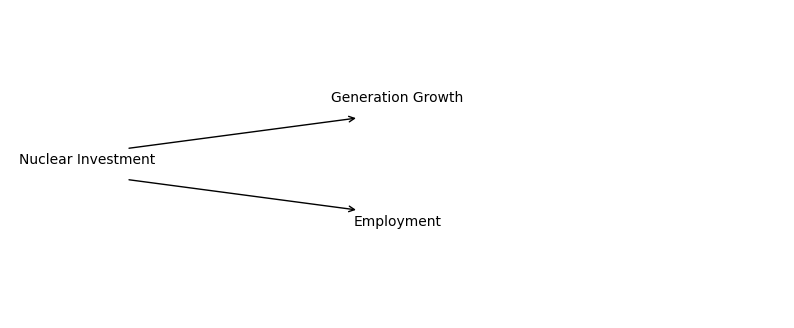

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,4))

ax.text(0.1, 0.5, "Nuclear Investment", ha='center')
ax.text(0.5, 0.7, "Generation Growth", ha='center')
ax.text(0.5, 0.3, "Employment", ha='center')

ax.annotate("", xy=(0.45,0.65), xytext=(0.15,0.55),
            arrowprops=dict(arrowstyle="->"))

ax.annotate("", xy=(0.45,0.35), xytext=(0.15,0.45),
            arrowprops=dict(arrowstyle="->"))

ax.set_axis_off()
plt.show()

## Research Question

Does nuclear electricity production correlate with employment trends 
in the U.S. utilities sector?

This analysis examines:

- Long-term trends in nuclear electricity production  
- Long-term employment trends in utilities  
- Whether these variables move together over time  

## Data Sources

This analysis uses time-series data from FRED.

| Variable | FRED Code | Description |
|--------|--------|--------|
| Nuclear Electricity Production | IPN221113N | Industrial production index (2017 = 100) |
| Utilities Employment | CES4422000001 | Total employment in utilities sector |

In [2]:
import pandas as pd
from pathlib import Path 

import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

sns.set_style("whitegrid")

DATA_DIR = Path("..")/ "data"
utilityEmployment = pd.read_csv(DATA_DIR/ "CES4422000001.csv")

In [3]:
utilityEmployment.head(5)

,observation_date,CES4422000001
0,1964-01-01,476.3
1,1964-02-01,476.6
2,1964-03-01,476.7
3,1964-04-01,477.0
4,1964-05-01,478.8


In [4]:
utilityEmployment.info()

<class 'pandas.DataFrame'>
RangeIndex: 746 entries, 0 to 745
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  746 non-null    str    
 1   CES4422000001     746 non-null    float64
dtypes: float64(1), str(1)
memory usage: 11.8 KB


In [5]:
utilityEmployment.columns = ['observation_date', 'utilities_employment']
# Testing updated table output 
utilityEmployment.head(10)

,observation_date,utilities_employment
0,1964-01-01,476.3
1,1964-02-01,476.6
2,1964-03-01,476.7
3,1964-04-01,477.0
4,1964-05-01,478.8
5,1964-06-01,474.3
6,1964-07-01,476.4
7,1964-08-01,476.6
8,1964-09-01,477.9
9,1964-10-01,479.3


In [6]:
utilityEmployment['observation_date'] = pd.to_datetime(utilityEmployment['observation_date'])
utilityEmployment = utilityEmployment.sort_values(['observation_date'])
utilityEmployment = utilityEmployment.set_index('observation_date')
utilityEmployment.head(5) #To test updated records remove once done. 


,utilities_employment
observation_date,
1964-01-01,476.3
1964-02-01,476.6
1964-03-01,476.7
1964-04-01,477.0
1964-05-01,478.8


## Descriptive Overview of the Time Series 

This section helps to verify the structure of the dataset, confirming but not limited to data-types, and an overall descriptive overview of the dataset before data visualisation and any further adjustments to prepare the datset for analysis. 

In [7]:
utilityEmployment.describe().T

,count,mean,std,min,25%,50%,75%,max
utilities_employment,746.0,600.044102,71.715906,474.3,552.1,575.85,651.375,741.9


# Exploratory Trend Analysis 

## Figure 1: Indexed Comparison (Full Sample: 1970–Present)

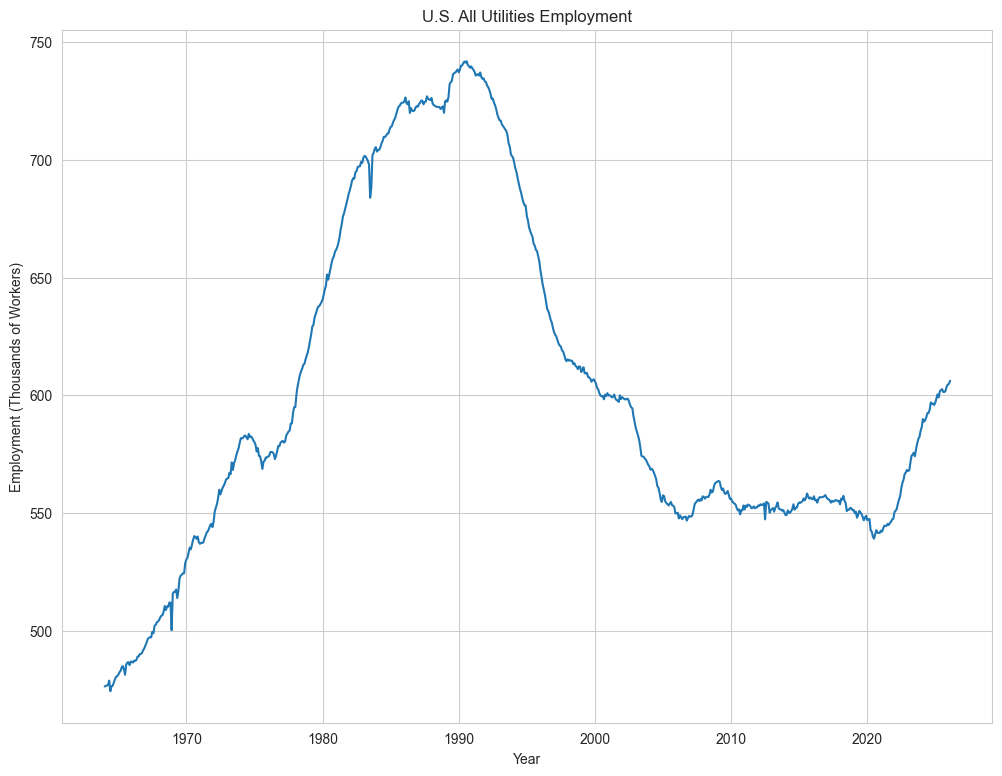

In [8]:
fig, ax = plt.subplots(figsize = (12,9))

ax.plot(utilityEmployment.index, utilityEmployment['utilities_employment'])
ax.set_title('U.S. All Utilities Employment')
ax.set_xlabel( xlabel = 'Year')
ax.set_ylabel('Employment (Thousands of Workers)')
ax.grid(True)
plt.show()


## Interpretation Draft 
Beginning in the early 1970's, the utility rate employment count by year began its development phase. From Figure 1, the data suggests that the developmental and growth phase of utility employment boomed from the 1970's-mid 1990's. This growth suggest a rise in demand for workers to fulfil the utilities sector while as company's expanded. However, after the mid 1990s towards the early 2000's  we see the employment number dropped significantly suggesting a softening job market for the utility sector likely  not requiring as many workers as was necessary during its deployment stage, in the early 1970's. From the 2000's onward, there is a slight recovery of employment number count but nothing to suggest a significant expansion in labour supply until an appreciation of workers around the same time as covid-19 pandemic ended. The data for that matter, does not suggest that following the Covid-19 pandemic, the utilites sector recovered as that sort of analysis will need to be conducted with stronger macroeconomic variables not yet available in Figure 1. 

## Interpretation Revised 
Utilities sector employment in the United States exhibits a clear multi-phase trajectory over the observed period. Beginning in the early 1970s, employment rises steadily, reflecting a period of expansion in utility infrastructure and growing demand for labor. This growth accelerates through the late 1970s and 1980s, peaking in the early-to-mid 1990s, which likely corresponds to the culmination of large-scale energy system development and capital deployment.

Following this peak, employment declines sharply from the mid-1990s into the early 2000s. This contraction suggests a structural shift within the utilities sector, where labor demand decreased despite continued operation of existing infrastructure. Possible explanations include technological improvements, operational efficiencies, and a transition from construction-intensive activity toward maintenance and optimization of established systems.

From the early 2000s onward, employment levels stabilize at a lower baseline, with only modest fluctuations. While there is a slight recovery in recent years, particularly following the COVID-19 pandemic, the data does not indicate a return to the earlier expansionary employment levels. However, attributing post-pandemic changes to broader macroeconomic recovery requires additional variables and is not directly supported by this figure alone.

Overall, the trend suggests that utilities sector employment is closely tied to periods of infrastructure expansion, but does not scale proportionally once systems mature, indicating a shift toward a more capital-intensive and efficiency-driven sector over time.

## Exploratory Analysis with 12 month Moving Average 

## Figure 2: Indexed Comparison (Rebased: 1990–Present)

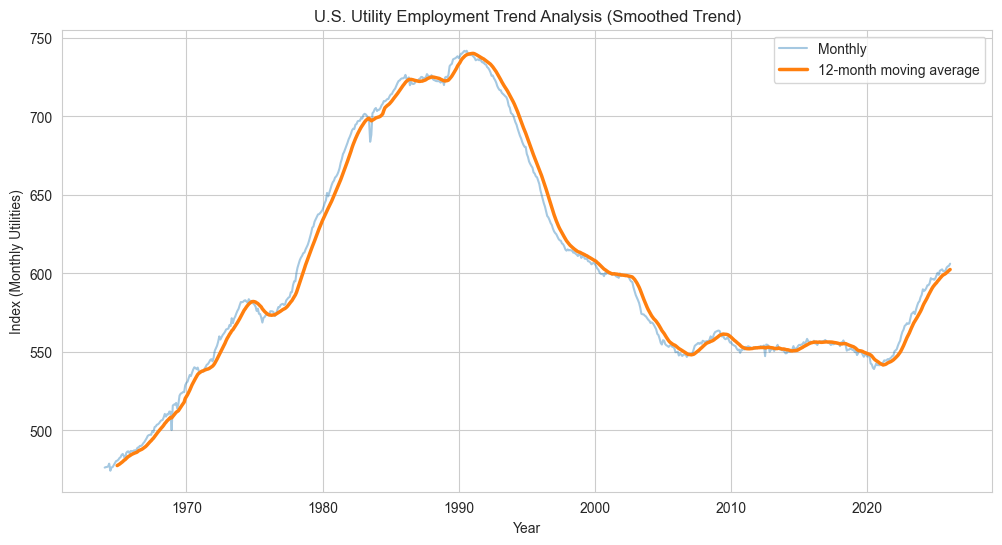

In [9]:
utilityEmployment['moving12'] = utilityEmployment['utilities_employment'].rolling(12).mean()
# ax.plot(nuclearProduction.index, nuclearProduction['nuclear_generation'], alpha=0.4, label='Monthly')
# ax.plot(nuclearProduction.index, nuclearProduction['rolling_12'], linewidth=2.5, label='12-Month Average')
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(utilityEmployment.index, utilityEmployment['utilities_employment'], alpha = 0.4, label= "Monthly" )
ax.plot(utilityEmployment.index, utilityEmployment['moving12'], linewidth = 2.5,  label= "12-month moving average" )

ax.set_title('U.S. Utility Employment Trend Analysis (Smoothed Trend)')
ax.set_xlabel('Year')
ax.set_ylabel('Index (Monthly Utilities)')
ax.legend()

ax.grid(True)
plt.show()

## Initial Data Inspection of Nuclear Production and Utilities Employment 

In [10]:
nuclearProduction = pd.read_csv(DATA_DIR/ "IPN221113N.csv")
nuclearProduction.columns = ['observation_date', 'nuclear_generation']
nuclearProduction['observation_date'] = pd.to_datetime(nuclearProduction['observation_date'])
nuclearProduction = nuclearProduction.sort_values('observation_date')
nuclearProduction = nuclearProduction.set_index('observation_date')
nuclearProduction.head()

,nuclear_generation
observation_date,
1972-01-01,6.1328
1972-02-01,5.5819
1972-03-01,6.1460
1972-04-01,5.3926
1972-05-01,4.2312


## Employment 

In [11]:
employment = pd.read_csv("../data/CES4422000001.csv")
employment.columns = ["date", "utilities_employment"]
employment["date"] = pd.to_datetime(employment["date"])
employment = employment.set_index("date")

In [12]:
df = nuclearProduction.join(employment, how="inner").dropna()

In [13]:
employment.describe().T

,count,mean,std,min,25%,50%,75%,max
utilities_employment,746.0,600.044102,71.715906,474.3,552.1,575.85,651.375,741.9


In [14]:
df_indexed = df / df.iloc[0] * 100

In [15]:
df_recent = df.loc["1990":].copy()
df_recent_indexed = df_recent / df_recent.iloc[0] * 100

### Nuclear Production Descriptive Analysis

In [16]:
nuclearProduction.describe().T 

,count,mean,std,min,25%,50%,75%,max
nuclear_generation,648.0,73.726406,30.174053,4.2312,45.960825,85.93525,99.244675,109.1925


## Figure 3: Exploratory Analysis Combining All Utilities Employment and U.S. Nuclear Production 


In [17]:
df = nuclearProduction.join(employment, how="inner")
df_rebased = df.loc["1990":].copy()
df_rebased = df_rebased / df_rebased.iloc[0] * 100
df = df.dropna()



## Figure 3: Indexed Comparison of Nuclear Generation and Utilities Employment

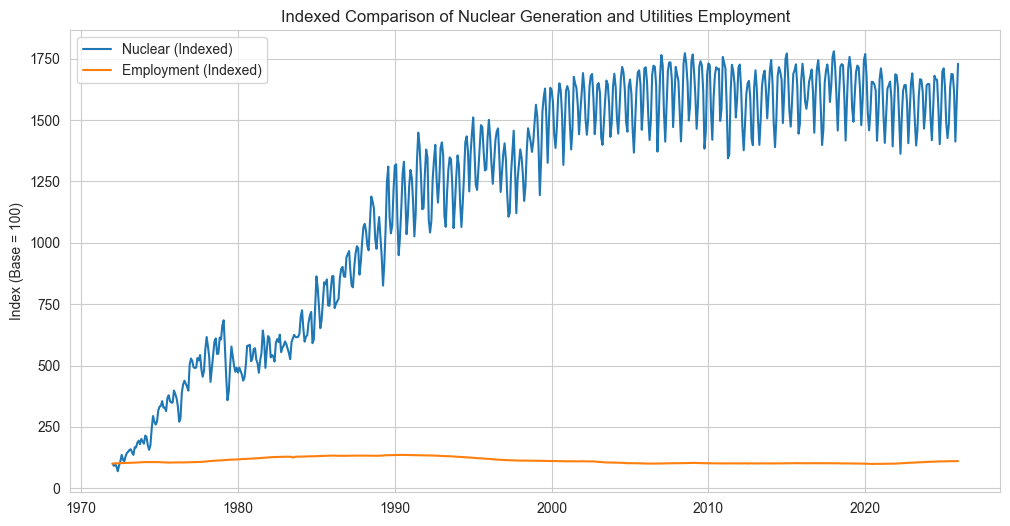

In [18]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(df_indexed.index, df_indexed["nuclear_generation"], label="Nuclear (Indexed)")
ax.plot(df_indexed.index, df_indexed["utilities_employment"], label="Employment (Indexed)")

ax.set_title("Indexed Comparison of Nuclear Generation and Utilities Employment")
ax.set_ylabel("Index (Base = 100)")

ax.legend()
plt.show()

## Interpretation 

Figure 1, U.S. All Utilities Employment and Figure 3, Indexed Comparison of Nuclear Generation and Utilities Employment, reflect two distinct relationships, the developmental phase and the stabilization phase of U.S. utility sector. Figure 1, from the late 1970-s--1980's reflect a development market requiring a large supply of workers to build, manage, and conduct operations to bring capital development afloat. However, Figure2, an adjusted reflection of the U.S. utilities labour force suggests that as nuclear energy construction and growth began to stablize in the late 1990's-present, the need for a large labour force  was not necessary as construction growth softened as it adjusted into a stabilization phase (Figure 2). Although following covid, figure 3 reflets partial recovery, the pandemic does not suggest that it was a signifiant indicator of recovery. Further marcoeconomic variables, are necessary to analyze such a change in the labour market for U.S. Utilities sector. However, figure 3 indicates that as Nuclear Energy production reached a stabilization phase with outputs remaining strong, demand labour market for workers to maintain plants and construction softened as the early 2000's rolled forward. 

## Interpretation (Revised)
Figures 1–3 collectively illustrate a structural shift in the relationship between nuclear electricity production and utilities sector employment in the United States, characterized by a transition from a developmental phase to a stabilization phase.

During the late 1970s through the early 1990s, Figure 1 shows a sustained increase in utilities employment, reflecting a period of expansion in energy infrastructure and system development. This trend is consistent with a construction-intensive phase, where large-scale investment in nuclear and broader utility systems required substantial labor inputs for plant construction, grid expansion, and operational deployment.

Figure 2 reinforces this pattern by smoothing short-term fluctuations, highlighting a clear upward trajectory in employment followed by a peak in the early 1990s. After this peak, employment declines significantly into the early 2000s, indicating a shift away from expansionary labor demand. This suggests that once major infrastructure projects were completed, the sector transitioned toward maintenance and operational efficiency rather than continued workforce expansion.

Figure 3 provides a comparative perspective by indexing nuclear electricity generation and utilities employment. While nuclear generation continues to grow substantially and later stabilizes at a high level of output, employment does not follow a proportional trajectory. Instead, employment remains relatively flat or declines after the mid-1990s, despite sustained production levels.

This divergence indicates that nuclear energy production is not labor-proportional in the long run. As the sector matured, increases in output were driven more by capital investment, technological improvements, and operational efficiencies rather than increases in workforce size.

Although there is a modest recovery in employment following the COVID-19 pandemic, the data does not provide sufficient evidence to attribute this change to a structural shift in the labor market. Additional macroeconomic variables would be required to assess the significance of this recovery.

Overall, the findings suggest that the utilities sector transitions from labor-intensive growth during infrastructure expansion to a more capital-intensive and efficiency-driven model once systems reach maturity.

The following section synthesizes insights from the full-period and rebased 
comparisons to assess the relationship between nuclear electricity production 
and utilities sector employment.

## Data Reference/ Citations
U.S. Bureau of Labor Statistics, All Employees, Utilities [CES4422000001], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/CES4422000001, March 19, 2026.

Source Code: CES4422000001